In [1]:
import sys
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent))

from datasets.data import ERA5MSWX, MSWXDWD, ISIMIP_ERA5

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

## Configuration and Data Loading

In [2]:
# Configuration
VARIABLES = ['pr', 'tasmax']  # Analyze both variables
YEARS = [2020, 2021, 2022, 2023]  # ISIMIP only available through 2023

# Data paths
BASE_PATH = "/data01/FDS/muduchuru/physicsnemo/examples/weather/corrdiff/"
ISIMIP_PATH = "/data01/FDS/muduchuru/Atmos/ISIMIP_ERA5/"

# Define spatial domain (Germany)
LON_MIN, LON_MAX = 5.5, 15.5
LAT_MIN, LAT_MAX = 47.0, 55.5

# Output directory
OUTPUT_DIR = Path('outputs') / 'spatial_spectra'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Analyzing variables: {VARIABLES}")
print(f"Years: {YEARS}")
print(f"Base path: {BASE_PATH}")
print(f"ISIMIP path: {ISIMIP_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Analyzing variables: ['pr', 'tasmax']
Years: [2020, 2021, 2022, 2023]
Base path: /data01/FDS/muduchuru/physicsnemo/examples/weather/corrdiff/
ISIMIP path: /data01/FDS/muduchuru/Atmos/ISIMIP_ERA5/
Output directory: outputs/spatial_spectra


In [3]:
# Load datasets
print("Loading 10km ERA5-MSWX data (ERA5 input + 10km prediction)...")
era5mswx = ERA5MSWX(base_path=BASE_PATH)
era5mswx.load(YEARS)

print("\nLoading 1km MSWX-DWD data (1km prediction + DWD truth)...")
mswxdwd = MSWXDWD(base_path=BASE_PATH)
mswxdwd.load(YEARS)

print("\nLoading ISIMIP BCSD data for pr...")
isimip_pr = ISIMIP_ERA5(base_path=ISIMIP_PATH, variable='pr')
isimip_pr.load(YEARS)

print("Loading ISIMIP BCSD data for tasmax...")
isimip_tasmax = ISIMIP_ERA5(base_path=ISIMIP_PATH, variable='tasmax')
isimip_tasmax.load(YEARS)

print("\nAll datasets loaded successfully!")

Loading 10km ERA5-MSWX data (ERA5 input + 10km prediction)...
Loading 10km ERA5-MSWX data...
Found 4 files for 10km model
Years: [2020, 2021, 2022, 2023]
Assigning coordinates from inv dataset (time, lat, lon) to all datasets...
  Inv time length: 1461
  Input time length: 1461
  Prediction time length: 1461
  Truth time length: 1461
Converting ERA5 input precipitation from m/day to mm/day...
Converting ERA5 input tas from Kelvin to Celsius...
Converting ERA5 input tasmin from Kelvin to Celsius...
Converting ERA5 input tasmax from Kelvin to Celsius...
10km data loaded - Time range: 2020-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
10km grid shape: (128, 128)

Loading 1km MSWX-DWD data (1km prediction + DWD truth)...

Loading 1km MSWX-DWD data...
Found 4 files for 1km model
Years: [2020, 2021, 2022, 2023]
Assigning coordinates from inv dataset (time, lat, lon) to all datasets...
  Inv time length: 1461
  Input time length: 1461
  Prediction time length: 1461
  Truth time le

## Helper Functions for Spatial Periodogram Analysis

In [4]:
def radial_profile(data, center=None):
    """
    Calculate radially averaged power spectrum.
    
    Parameters:
    -----------
    data : 2D array
        Power spectrum from 2D FFT
    center : tuple, optional
        Center coordinates (cy, cx). If None, use array center
    
    Returns:
    --------
    radial_mean : array
        Radially averaged power
    """
    y, x = np.indices(data.shape)
    if center is None:
        center = np.array([(y.max()-y.min())/2.0, (x.max()-x.min())/2.0])
    
    r = np.sqrt((y - center[0])**2 + (x - center[1])**2)
    r = r.astype(int)
    
    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())
    radial_mean = tbin / nr
    
    return radial_mean


def calculate_spatial_power_spectrum(data_array, dx_km=1.0):
    """
    Calculate spatial power spectrum from 2D spatial fields.
    
    Parameters:
    -----------
    data_array : xr.DataArray
        DataArray with time and spatial dimensions (y, x) or (lat, lon)
    dx_km : float
        Grid spacing in kilometers
    
    Returns:
    --------
    wavelengths : array
        Spatial wavelengths in km
    power : array
        Radially averaged power spectral density
    """
    # Determine spatial dimensions
    spatial_dims = []
    for dim in ['y', 'x', 'lat', 'lon']:
        if dim in data_array.dims:
            spatial_dims.append(dim)
    
    if len(spatial_dims) != 2:
        raise ValueError(f"Need exactly 2 spatial dimensions. Found: {spatial_dims}")
    
    # Time-average first to get mean spatial field
    if 'time' in data_array.dims:
        mean_field = data_array.mean(dim='time').values
    else:
        mean_field = data_array.values
    
    # Remove NaNs (set to mean)
    mean_field = np.nan_to_num(mean_field, nan=np.nanmean(mean_field))
    
    # 2D FFT
    fft_2d = np.fft.fft2(mean_field)
    power_2d = np.abs(fft_2d)**2
    
    # Shift zero frequency to center
    power_2d_shifted = np.fft.fftshift(power_2d)
    
    # Radially average
    radial_power = radial_profile(power_2d_shifted)
    
    # Calculate spatial frequencies and wavelengths
    ny, nx = mean_field.shape
    freq_x = np.fft.fftfreq(nx, d=dx_km)
    freq_y = np.fft.fftfreq(ny, d=dx_km)
    
    # Maximum frequency (Nyquist)
    freq_max = np.sqrt(freq_x.max()**2 + freq_y.max()**2)
    
    # Create wavenumber array corresponding to radial bins
    n_radial = len(radial_power)
    wavenumbers = np.linspace(0, freq_max, n_radial)
    
    # Convert to wavelengths (km)
    wavelengths = np.zeros_like(wavenumbers)
    wavelengths[1:] = 1.0 / wavenumbers[1:]
    wavelengths[0] = np.inf
    
    return wavelengths, radial_power


def temporal_mean_spatial_spectrum(data_array, dx_km=1.0, n_samples=50):
    """
    Calculate spatial power spectrum averaged over multiple time steps.
    
    Parameters:
    -----------
    data_array : xr.DataArray
        DataArray with time and spatial dimensions
    dx_km : float
        Grid spacing in kilometers
    n_samples : int
        Number of time steps to sample for averaging
    
    Returns:
    --------
    wavelengths : array
        Spatial wavelengths in km
    power : array
        Time-averaged radially averaged power spectral density
    """
    # Determine spatial dimensions
    spatial_dims = []
    for dim in ['y', 'x', 'lat', 'lon']:
        if dim in data_array.dims:
            spatial_dims.append(dim)
    
    if len(spatial_dims) != 2:
        raise ValueError(f"Need exactly 2 spatial dimensions. Found: {spatial_dims}")
    
    # Sample time steps uniformly
    n_times = len(data_array.time)
    sample_indices = np.linspace(0, n_times-1, min(n_samples, n_times), dtype=int)
    
    all_powers = []
    all_wavelengths = None
    
    for idx in sample_indices:
        field = data_array.isel(time=idx).values
        
        # Remove NaNs
        field = np.nan_to_num(field, nan=np.nanmean(field))
        
        # Skip if all NaN
        if not np.any(np.isfinite(field)):
            continue
        
        # 2D FFT
        fft_2d = np.fft.fft2(field)
        power_2d = np.abs(fft_2d)**2
        power_2d_shifted = np.fft.fftshift(power_2d)
        
        # Radially average
        radial_power = radial_profile(power_2d_shifted)
        all_powers.append(radial_power)
        
        if all_wavelengths is None:
            # Calculate wavelengths once
            ny, nx = field.shape
            freq_x = np.fft.fftfreq(nx, d=dx_km)
            freq_y = np.fft.fftfreq(ny, d=dx_km)
            freq_max = np.sqrt(freq_x.max()**2 + freq_y.max()**2)
            n_radial = len(radial_power)
            wavenumbers = np.linspace(0, freq_max, n_radial)
            all_wavelengths = np.zeros_like(wavenumbers)
            all_wavelengths[1:] = 1.0 / wavenumbers[1:]
            all_wavelengths[0] = np.inf
    
    # Average powers across time
    mean_power = np.mean(all_powers, axis=0)
    
    return all_wavelengths, mean_power


print("Spatial periodogram helper functions defined.")

Spatial periodogram helper functions defined.


## Calculate Spatial Power Spectra for All Datasets

In [5]:
# Calculate spatial power spectra for both variables
print("Calculating spatial power spectra...\n")

# Grid spacings
DX_ERA5 = 10.0  # ERA5MSWX is 10 km
DX_1KM = 1.0    # MSWXDWD and ISIMIP are 1 km

# Store results in dictionaries
spectra = {'pr': {}, 'tasmax': {}}

for var in VARIABLES:
    print(f"\n=== Processing {var.upper()} ===")
    
    # Load ISIMIP data
    if var == 'pr':
        isimip_data = isimip_pr.prediction.sel(
            lon=slice(LON_MIN, LON_MAX),
            lat=slice(LAT_MIN, LAT_MAX)
        )
    else:
        isimip_data = isimip_tasmax.prediction.sel(
            lon=slice(LON_MIN, LON_MAX),
            lat=slice(LAT_MIN, LAT_MAX)
        )
    
    # Calculate spectra
    wave_era5, power_era5 = temporal_mean_spatial_spectrum(era5mswx.input[var], dx_km=DX_ERA5, n_samples=50)
    print(f"✓ ERA5 spatial spectrum calculated")
    
    wave_10km, power_10km = temporal_mean_spatial_spectrum(era5mswx.prediction[var].isel(ensemble=0), dx_km=DX_ERA5, n_samples=50)
    print(f"✓ Prediction 10km spatial spectrum calculated")
    
    wave_1km, power_1km = temporal_mean_spatial_spectrum(mswxdwd.prediction[var].isel(ensemble=0), dx_km=DX_1KM, n_samples=50)
    print(f"✓ Prediction 1km spatial spectrum calculated")
    
    wave_isimip, power_isimip = temporal_mean_spatial_spectrum(isimip_data[var], dx_km=DX_ERA5, n_samples=50)
    print(f"✓ ISIMIP BCSD spatial spectrum calculated")
    
    wave_dwd, power_dwd = temporal_mean_spatial_spectrum(mswxdwd.truth[var], dx_km=DX_1KM, n_samples=50)
    print(f"✓ DWD spatial spectrum calculated")
    
    wave_mswx, power_mswx = temporal_mean_spatial_spectrum(era5mswx.truth[var], dx_km=DX_ERA5, n_samples=50)
    print(f"✓ MSWX 10km spatial spectrum calculated")
    
    # Store results
    spectra[var] = {
        'era5': (wave_era5, power_era5),
        '10km': (wave_10km, power_10km),
        '1km': (wave_1km, power_1km),
        'isimip': (wave_isimip, power_isimip),
        'mswx': (wave_mswx, power_mswx),
        'dwd': (wave_dwd, power_dwd)
    }
print("\n\nAll spatial power spectra calculated successfully!")

Calculating spatial power spectra...


=== Processing PR ===
✓ ERA5 spatial spectrum calculated
✓ Prediction 10km spatial spectrum calculated
✓ Prediction 1km spatial spectrum calculated
✓ ISIMIP BCSD spatial spectrum calculated
✓ DWD spatial spectrum calculated
✓ MSWX 10km spatial spectrum calculated

=== Processing TASMAX ===
✓ ERA5 spatial spectrum calculated
✓ Prediction 10km spatial spectrum calculated
✓ Prediction 1km spatial spectrum calculated
✓ ISIMIP BCSD spatial spectrum calculated
✓ DWD spatial spectrum calculated
✓ MSWX 10km spatial spectrum calculated


All spatial power spectra calculated successfully!


## Visualization: Spatial Power Spectral Density (PR and TASMAX)

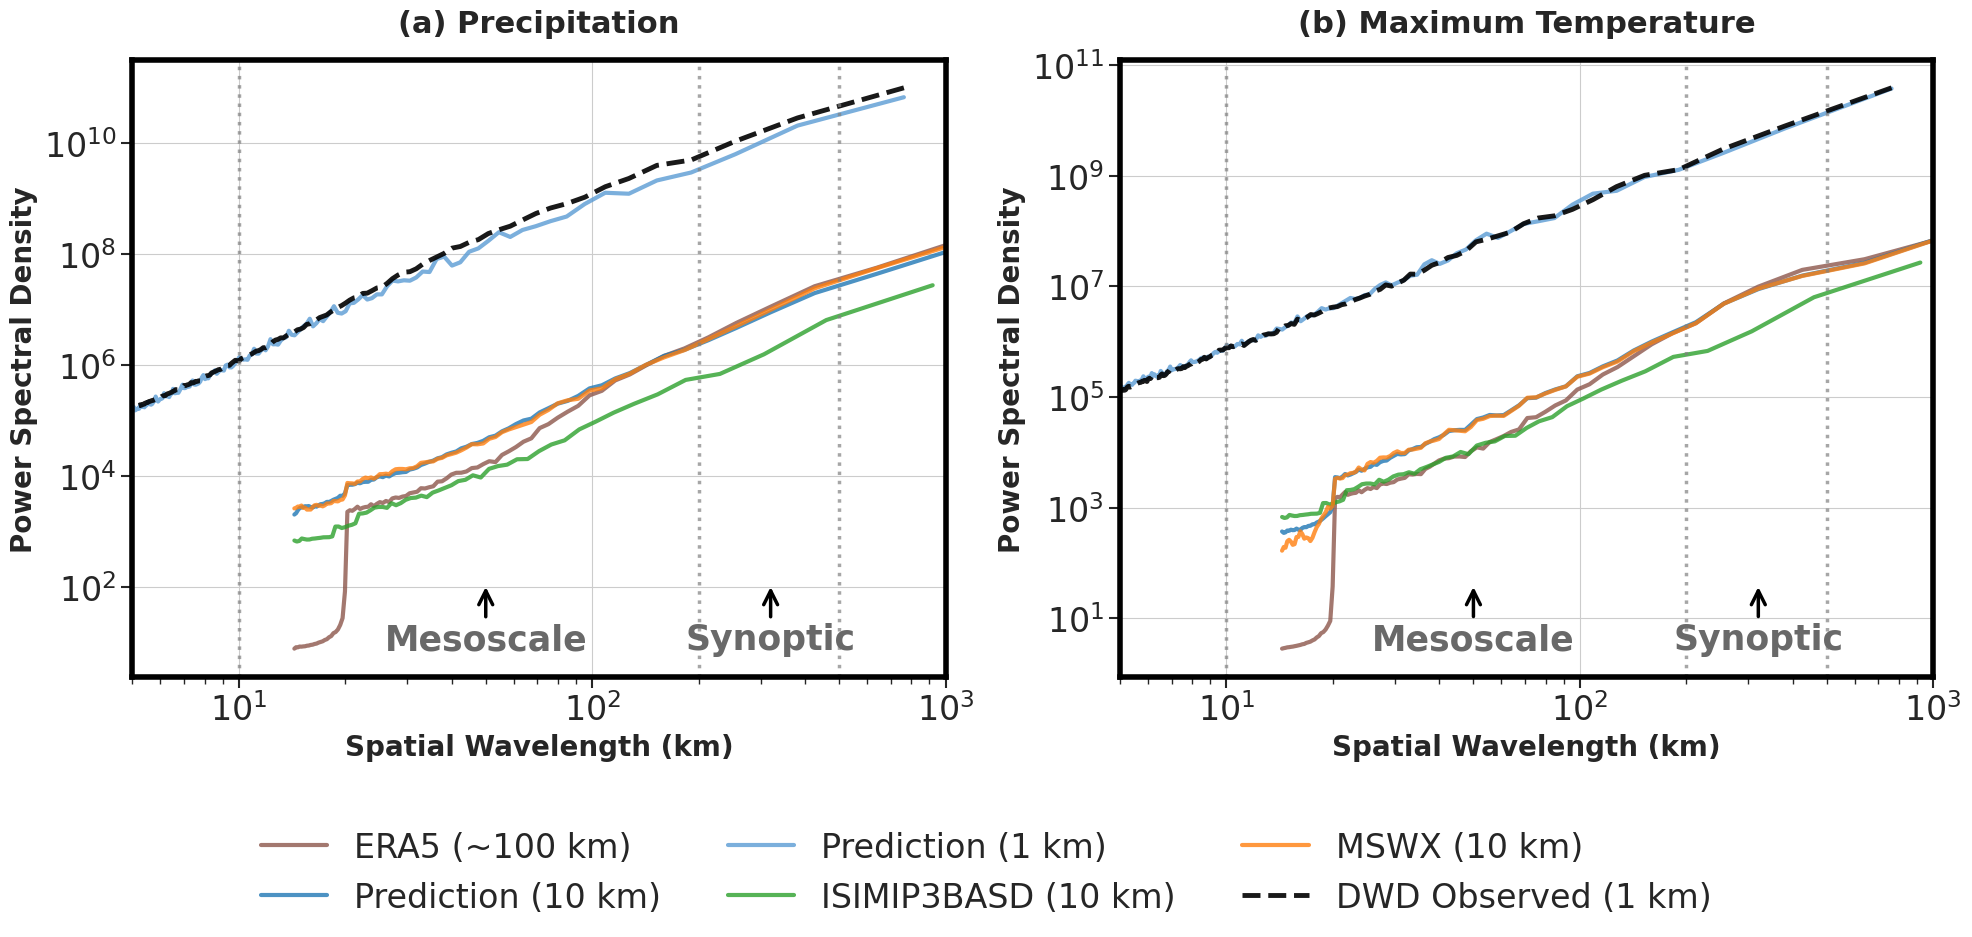

Saved: outputs/spatial_spectra/spatial_power_spectrum_pr_tasmax.png


In [7]:
# Create side-by-side plot: PR (left) and TASMAX (right)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Increase font sizes globally for this plot
plt.rcParams.update({'font.size': 16})

# Define colors (matching validate_tasmax.py quantile difference plot)
color_era5 = '#8c564b'
color_10km = '#1f77b4'
color_1km = '#5a9bd4'
color_isimip = '#2ca02c'
color_mswx = '#ff7f0e'
color_dwd = 'black'

for idx, (ax, var) in enumerate([(ax1, 'pr'), (ax2, 'tasmax')]):
    # Extract data for this variable
    wave_era5, power_era5 = spectra[var]['era5']
    wave_10km, power_10km = spectra[var]['10km']
    wave_1km, power_1km = spectra[var]['1km']
    wave_mswx, power_mswx = spectra[var]['mswx']
    wave_dwd, power_dwd = spectra[var]['dwd']
    
    # Filter valid wavelengths
    valid_era5 = (wave_era5 > 0) & (wave_era5 < 1e6) & np.isfinite(power_era5)
    valid_10km = (wave_10km > 0) & (wave_10km < 1e6) & np.isfinite(power_10km)
    valid_1km = (wave_1km > 0) & (wave_1km < 1e6) & np.isfinite(power_1km)
    valid_isimip = (wave_isimip > 0) & (wave_isimip < 1e6) & np.isfinite(power_isimip)
    valid_mswx = (wave_mswx > 0) & (wave_mswx < 1e6) & np.isfinite(power_mswx)
    valid_dwd = (wave_dwd > 0) & (wave_dwd < 1e6) & np.isfinite(power_dwd)
    
    # Only add labels for the first axis (to avoid duplicate legend entries)
    add_labels = (idx == 0)
    
    # Plot spectra with consistent colors
    ax.loglog(wave_era5[valid_era5], power_era5[valid_era5], 
               label='ERA5 (~100 km)' if add_labels else '', 
               linewidth=3, alpha=0.8, color=color_era5)
    ax.loglog(wave_10km[valid_10km], power_10km[valid_10km], 
               label='Prediction (10 km)' if add_labels else '', 
               linewidth=3, alpha=0.8, color=color_10km)
    ax.loglog(wave_1km[valid_1km], power_1km[valid_1km], 
               label='Prediction (1 km)' if add_labels else '', 
               linewidth=3, alpha=0.8, color=color_1km)
    ax.loglog(wave_isimip[valid_isimip], power_isimip[valid_isimip], 
               label='ISIMIP3BASD (10 km)' if add_labels else '', 
               linewidth=3, alpha=0.8, color=color_isimip)
    ax.loglog(wave_mswx[valid_mswx], power_mswx[valid_mswx], 
               label='MSWX (10 km)' if add_labels else '', 
               linewidth=3, alpha=0.8, color=color_mswx)
    ax.loglog(wave_dwd[valid_dwd], power_dwd[valid_dwd], 
               label='DWD Observed (1 km)' if add_labels else '', 
               linewidth=3.5, linestyle='--', color=color_dwd, alpha=0.9)
    
    # Add vertical lines and annotations for spatial scale regimes
    # Mesoscale boundaries (10-200 km)
    ax.axvline(10, color='gray', linestyle=':', linewidth=2.5, alpha=0.7)
    ax.axvline(200, color='gray', linestyle=':', linewidth=2.5, alpha=0.7)
    # Synoptic boundary (200-500 km) - only right boundary since left is shared with mesoscale
    ax.axvline(500, color='gray', linestyle=':', linewidth=2.5, alpha=0.7)
    
    # Get y-axis limits for positioning annotations
    ylim = ax.get_ylim()
    y_pos = 10**(np.log10(ylim[1]) - 0.85 * (np.log10(ylim[1]) - np.log10(ylim[0])))
    
    # Annotate Mesoscale region
    ax.annotate('Mesoscale', xy=(50, y_pos), xytext=(50, y_pos * .05),
                ha='center', va='bottom', fontsize=25, fontweight='bold',
                color='dimgray',
                arrowprops=dict(arrowstyle='->', lw=2.5, color='k'))
    
    # Annotate Synoptic region
    ax.annotate('Synoptic', xy=(320, y_pos), xytext=(320, y_pos * .05),
                ha='center', va='bottom', fontsize=25, fontweight='bold',
                color='dimgray',
                arrowprops=dict(arrowstyle='->', lw=2.5, color='k'))
    
    # Labels and formatting
    ax.set_xlabel('Spatial Wavelength (km)', fontsize=20, fontweight='bold')
    ax.set_ylabel('Power Spectral Density', fontsize=20, fontweight='bold')
    
    # Title
    var_title = '(a) Precipitation' if var == 'pr' else '(b) Maximum Temperature'
    ax.set_title(f'{var_title}', fontsize=22, fontweight='bold', pad=20)
    
    ax.set_xlim([5, 1000])
    for spine in ax.spines.values():
        spine.set_linewidth(4)
        spine.set_visible(True)
        spine.set_color('black')
    # Increase tick label size
    ax.tick_params(axis='both', which='major', labelsize=24, width=1.5, length=8)
    ax.tick_params(axis='both', which='minor', labelsize=24, width=1, length=5)

# Add legend with 3 columns below the plots (using handles from first axis only)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=24, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'spatial_power_spectrum_pr_tasmax.png', dpi=300, bbox_inches='tight')

plt.show()

print(f"Saved: {OUTPUT_DIR / 'spatial_power_spectrum_pr_tasmax.png'}")